In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
file_path = 'data/steam_games.csv'
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
#print(f"stopwords {list(stop_words)[:100]}")

[nltk_data] Downloading package stopwords to /home/marcos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/marcos/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:
def read_dataset(file_path):

    if not os.path.exists(file_path):
        print("ERRO: Arquivo de dados não encontrado!")
        return None

    df_complete = pd.read_csv(file_path)
    df_sample = df_complete.sample(n = 15000, random_state = 10)
    return df_sample

In [7]:
def clean_text(text):
    porter = PorterStemmer()
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens_clean = [word for word in tokens if word not in stop_words]
    tokens_stemmed=[porter.stem(word) for word in tokens_clean]
    return " ".join(tokens_stemmed)

In [8]:
df_bruto = read_dataset(file_path)

if df_bruto is not None:

    # Limpando o arquivo, selecionando colunas que podem ser utilizadas
    important = [
        'appid', 'name', 'genres', 'description', 'short_description'
    ]
    df = df_bruto[important].copy()
    display(df.head())

,appid,name,genres,description,short_description
19741,782610,Tank 51,Action;Adventure;Casual;Indie,Tank 51 is an increasingly difficult retro sty...,Tank 51 is an increasingly difficult retro sty...
9032,466910,Worm.is: The Game,Casual;Free to Play,** From the creators of Mitos.is: The Game (82...,Smash worms or slither trying! Warning: Incred...
4254,334960,Cell HD: emergence,Action;Indie;Simulation,Against the &quot;smart germs&quot; of tomorro...,Based on a 3D version of mathematician John Co...
7065,410120,AGON - The Mysterious Codex (Trilogy),Adventure,AGON - The Mysterious Codex is a trilogy featu...,Professor Hunt embarks on an adventure journey...
25168,960320,Ego Hearts,Free to Play;Indie,<strong>***USE GAMEPAD FOR BEST EXPERIENCE***<...,Ego Hearts is a small interactive reflection a...


In [9]:
game_descriptions_clean = df['description'].apply(clean_text)
#print(game_descriptions_clean.iloc[9])

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.6,min_df=10)
tfidf_matrix = vectorizer.fit_transform(game_descriptions_clean)
print(f"Formato da matriz: {tfidf_matrix.shape}")

Formato da matriz: (15000, 7779)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

#svd = TruncatedSVD(n_components = reuzindo_para, random_state = seed)
#trecho de código de https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
lsa_pipeline = make_pipeline(TruncatedSVD(n_components=2000, random_state=10), 
                              Normalizer(copy=False))
lsa=lsa_pipeline[0]
# Aplica tudo de uma vez na sua matriz TF-IDF
final_matrix = lsa_pipeline.fit_transform(tfidf_matrix)
#final_matrix = svd.fit_transform(tfidf_matrix)

print(f"original: {tfidf_matrix.shape}")
print(f"reduzido: {final_matrix.shape}")

original: (15000, 7779)
reduzido: (15000, 2000)


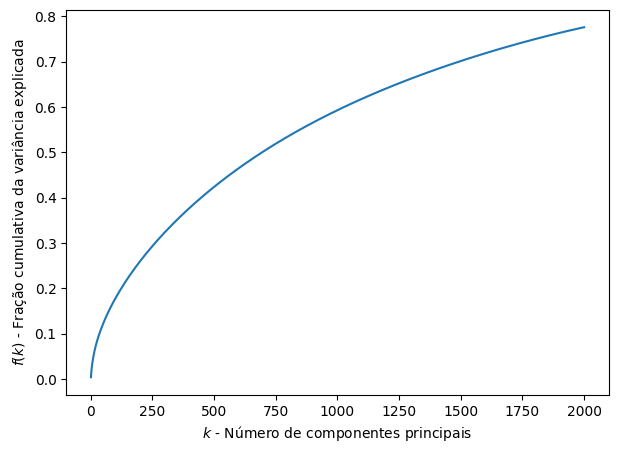

In [13]:
fig = plt.figure(figsize=(7, 5))
plt.plot([i for i in range(1, lsa.n_components + 1)], np.cumsum(lsa.explained_variance_ratio_))
plt.xlabel(r'$k$ - Número de componentes principais')
plt.ylabel(r'$f(k)$ - Fração cumulativa da variância explicada');

In [ ]:
from sklearn.cluster import KMeans
from sklearn import cluster, datasets
inertia = []

for i in range(1, 50):
  km = cluster.KMeans(n_clusters = i,init='k-means++')
  km.fit(final_matrix)
  inertia.append(km.inertia_)

plt.scatter(range(1, 50), inertia)
_ = plt.ylabel("Função Objetivo")
_ = plt.xlabel(r"$k$")

In [29]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import silhouette_samples, silhouette_score
#plota distribuição de dados de acordo com o valor do coeficiente de silhueta
def visualize_metricas_plot(k_init,k_final):
    range_cluster=range(k_init, k_final)

    inertia = []
    silhouette = []
    calinski = []
    davies = []
    
    for n_clusters in range_cluster:
        # Create a subplot with 1 row and 2 columns
        # fig, (ax1, ax2) = plt.subplots(1, 2)
        # fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        # ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        # ax1.set_ylim([0, len(final_matrix) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, random_state=10,init='k-means++', n_init = 10)
        cluster_labels = clusterer.fit_predict(final_matrix)

        # metrica do cotovelo
        inertia.append(clusterer.inertia_)
        
        silhouette_avg = silhouette_score(final_matrix, cluster_labels)
        silhouette.append(silhouette_avg)
        
        score_ch = calinski_harabasz_score(final_matrix, cluster_labels)
        calinski.append(score_ch)
        
        score_db = davies_bouldin_score(final_matrix, cluster_labels)
        davies.append(score_db)

        print(f"k={n_clusters} |Sillhouette: {silhouette_avg:.6f} | CH: {score_ch:.2f} | DB: {score_db:.2f}")

        # Compute the silhouette scores for each sample
        # sample_silhouette_values = silhouette_samples(final_matrix, cluster_labels)

        # y_lower = 10
        # for i in range(n_clusters):
        #     # Aggregate the silhouette scores for samples belonging to
        #     # cluster i, and sort them
        #     ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        #     ith_cluster_silhouette_values.sort()

        #     size_cluster_i = ith_cluster_silhouette_values.shape[0]
        #     y_upper = y_lower + size_cluster_i

        #     color = cm.nipy_spectral(float(i) / n_clusters)
        #     ax1.fill_betweenx(
        #         np.arange(y_lower, y_upper),
        #         0,
        #         ith_cluster_silhouette_values,
        #         facecolor=color,
        #         edgecolor=color,
        #         alpha=0.7,
        #     )

        #     # Label the silhouette plots with their cluster numbers at the middle
        #     ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        #     # Compute the new y_lower for next plot
        #     y_lower = y_upper + 10  # 10 for the 0 samples

        # ax1.set_title("The silhouette plot for the various clusters.")
        # ax1.set_xlabel("The silhouette coefficient values")
        # ax1.set_ylabel("Cluster label")

        # # The vertical line for average silhouette score of all the values
        # ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        # ax1.set_yticks([])  # Clear the yaxis labels / ticks
        # ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # # 2nd Plot showing the actual clusters formed
        # colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        # ax2.scatter(
        #     final_matrix[:, 0], final_matrix[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        # )

        # # Labeling the clusters
        # centers = clusterer.cluster_centers_
        # # Draw white circles at cluster centers
        # ax2.scatter(
        #     centers[:, 0],
        #     centers[:, 1],
        #     marker="o",
        #     c="white",
        #     alpha=1,
        #     s=200,
        #     edgecolor="k",
        # )

        # for i, c in enumerate(centers):
        #     ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        # ax2.set_title("The visualization of the clustered data.")
        # ax2.set_xlabel("Feature space for the 1st feature")
        # ax2.set_ylabel("Feature space for the 2nd feature")

        # plt.suptitle(
        #     "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        #     % n_clusters,
        #     fontsize=14,
        #     fontweight="bold",
        # )

    # Plotando os 3 gráficos lado a lado
    fig, axes = plt.subplots(4, 1, figsize=(10, 15))
    
    # Gráfico 1: Elbow
    axes[0].plot(range_cluster, inertia, marker='o')
    axes[0].set_title('Cotovelo')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('Inércia ')

    # Gráfico 1: silhouette
    axes[1].plot(range_cluster, silhouette, marker='o')
    axes[1].set_title('silhouette')
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('silhouette (Maior é melhor)')
        
    # Gráfico 3: Calinski-Harabasz
    axes[2].plot(range_cluster, calinski, marker='o', color='orange')
    axes[2].set_title('Calinski-Harabasz Score')
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Score (Maior é melhor)')
    
    # Gráfico 4: Davies-Bouldin
    axes[3].plot(range_cluster, davies, marker='o', color='green')
    axes[3].set_title('Davies-Bouldin Index')
    axes[3].set_xlabel('k')
    axes[3].set_ylabel('Score (Menor é melhor)')
    
    plt.tight_layout()
    plt.show()

k=20 |Sillhouette: 0.010775 | CH: 41.70 | DB: 7.13
k=21 |Sillhouette: 0.009997 | CH: 40.44 | DB: 7.66
k=22 |Sillhouette: 0.010847 | CH: 40.15 | DB: 6.91
k=23 |Sillhouette: 0.011389 | CH: 39.20 | DB: 7.15
k=24 |Sillhouette: 0.011355 | CH: 37.82 | DB: 7.03
k=25 |Sillhouette: 0.011760 | CH: 37.30 | DB: 6.97
k=26 |Sillhouette: 0.011916 | CH: 36.27 | DB: 7.02
k=27 |Sillhouette: 0.010126 | CH: 35.56 | DB: 7.00
k=28 |Sillhouette: 0.012430 | CH: 35.09 | DB: 6.76
k=29 |Sillhouette: 0.012153 | CH: 34.10 | DB: 7.03


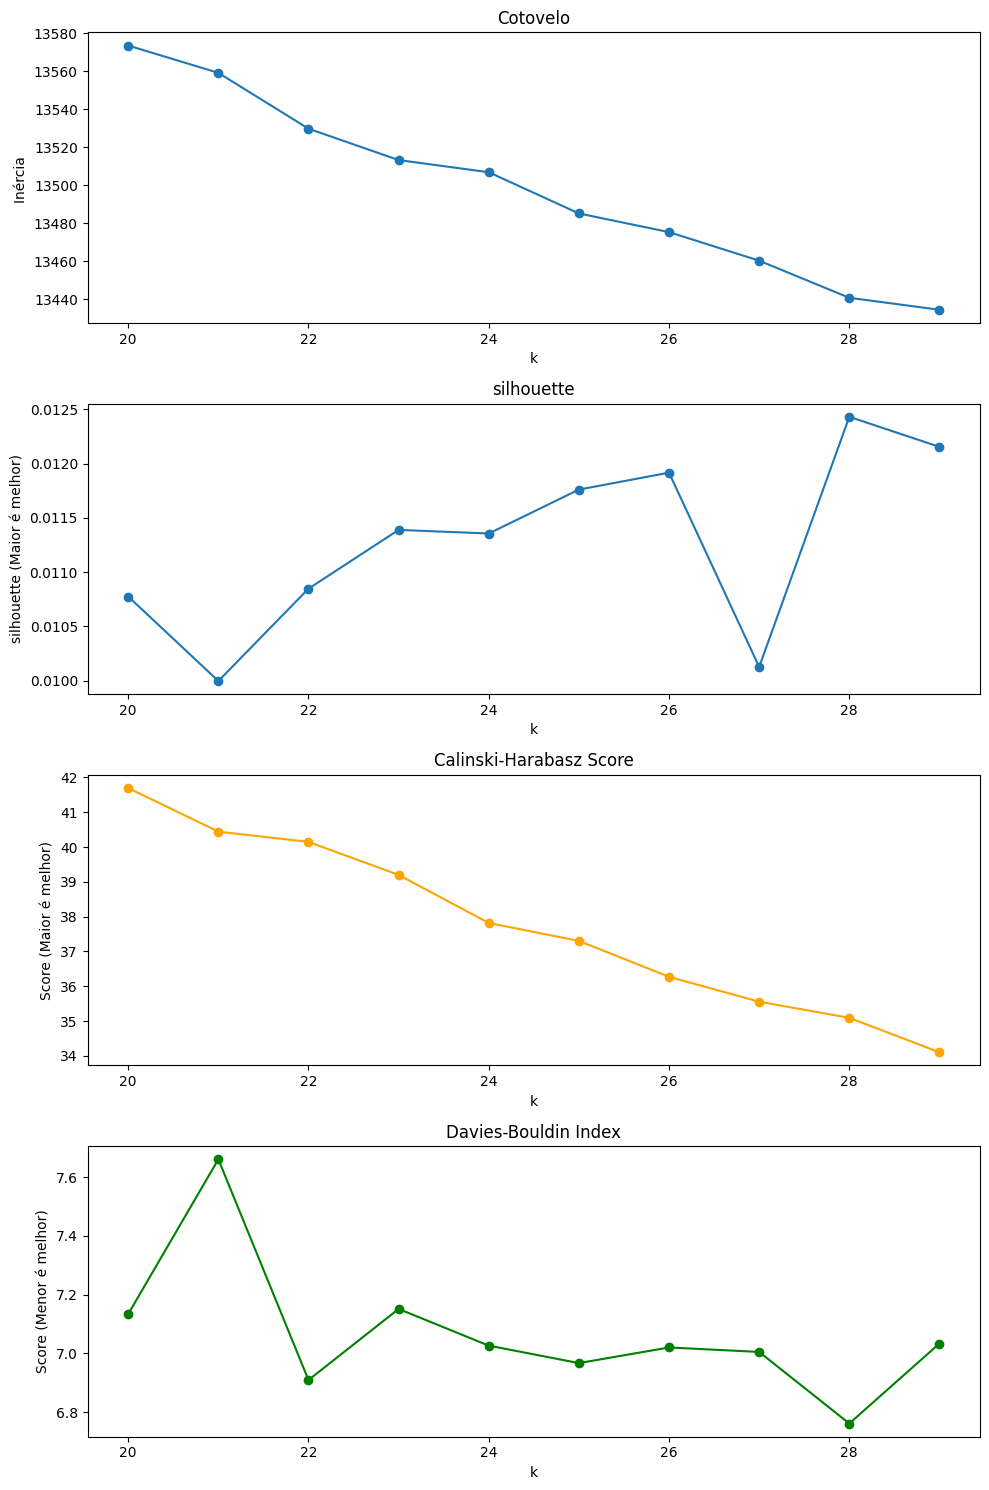

In [30]:
#k nesse intervalo parece bom
visualize_metricas_plot(20,30)

In [32]:
#Imprime as 10 palavras de maiores peso para cada cluster
#https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
kmeans=KMeans(n_clusters=22, random_state=10,init='k-means++', n_init = 10)
kmeans.fit_predict(final_matrix)
original_space_centroids = lsa.inverse_transform(kmeans.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(0,22):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()
    

Cluster 0: collector edit hidden wallpap exclus extra object standard bonu find 
Cluster 1: level platform challeng puzzl play jump get collect control obstacl 
Cluster 2: ship space planet alien galaxi system crew enemi new explor 
Cluster 3: puzzl solv level challeng logic featur color relax new play 
Cluster 4: stori adventur find mysteri puzzl world explor horror dark solv 
Cluster 5: build surviv farm citi world resourc new craft island manag 
Cluster 6: play get time use world new make featur level one 
Cluster 7: world magic hero charact power battl new adventur quest rpg 
Cluster 8: girl novel stori love end visual charact romanc quot choic 
Cluster 9: quot play stori mode player world new charact time one 
Cluster 10: zombi surviv weapon kill undead mode hord player survivor infect 
Cluster 11: dungeon monster item gener hero level explor enemi charact adventur 
Cluster 12: vr experi virtual vive realiti htc room oculu play control 
Cluster 13: tower defens enemi upgrad defend

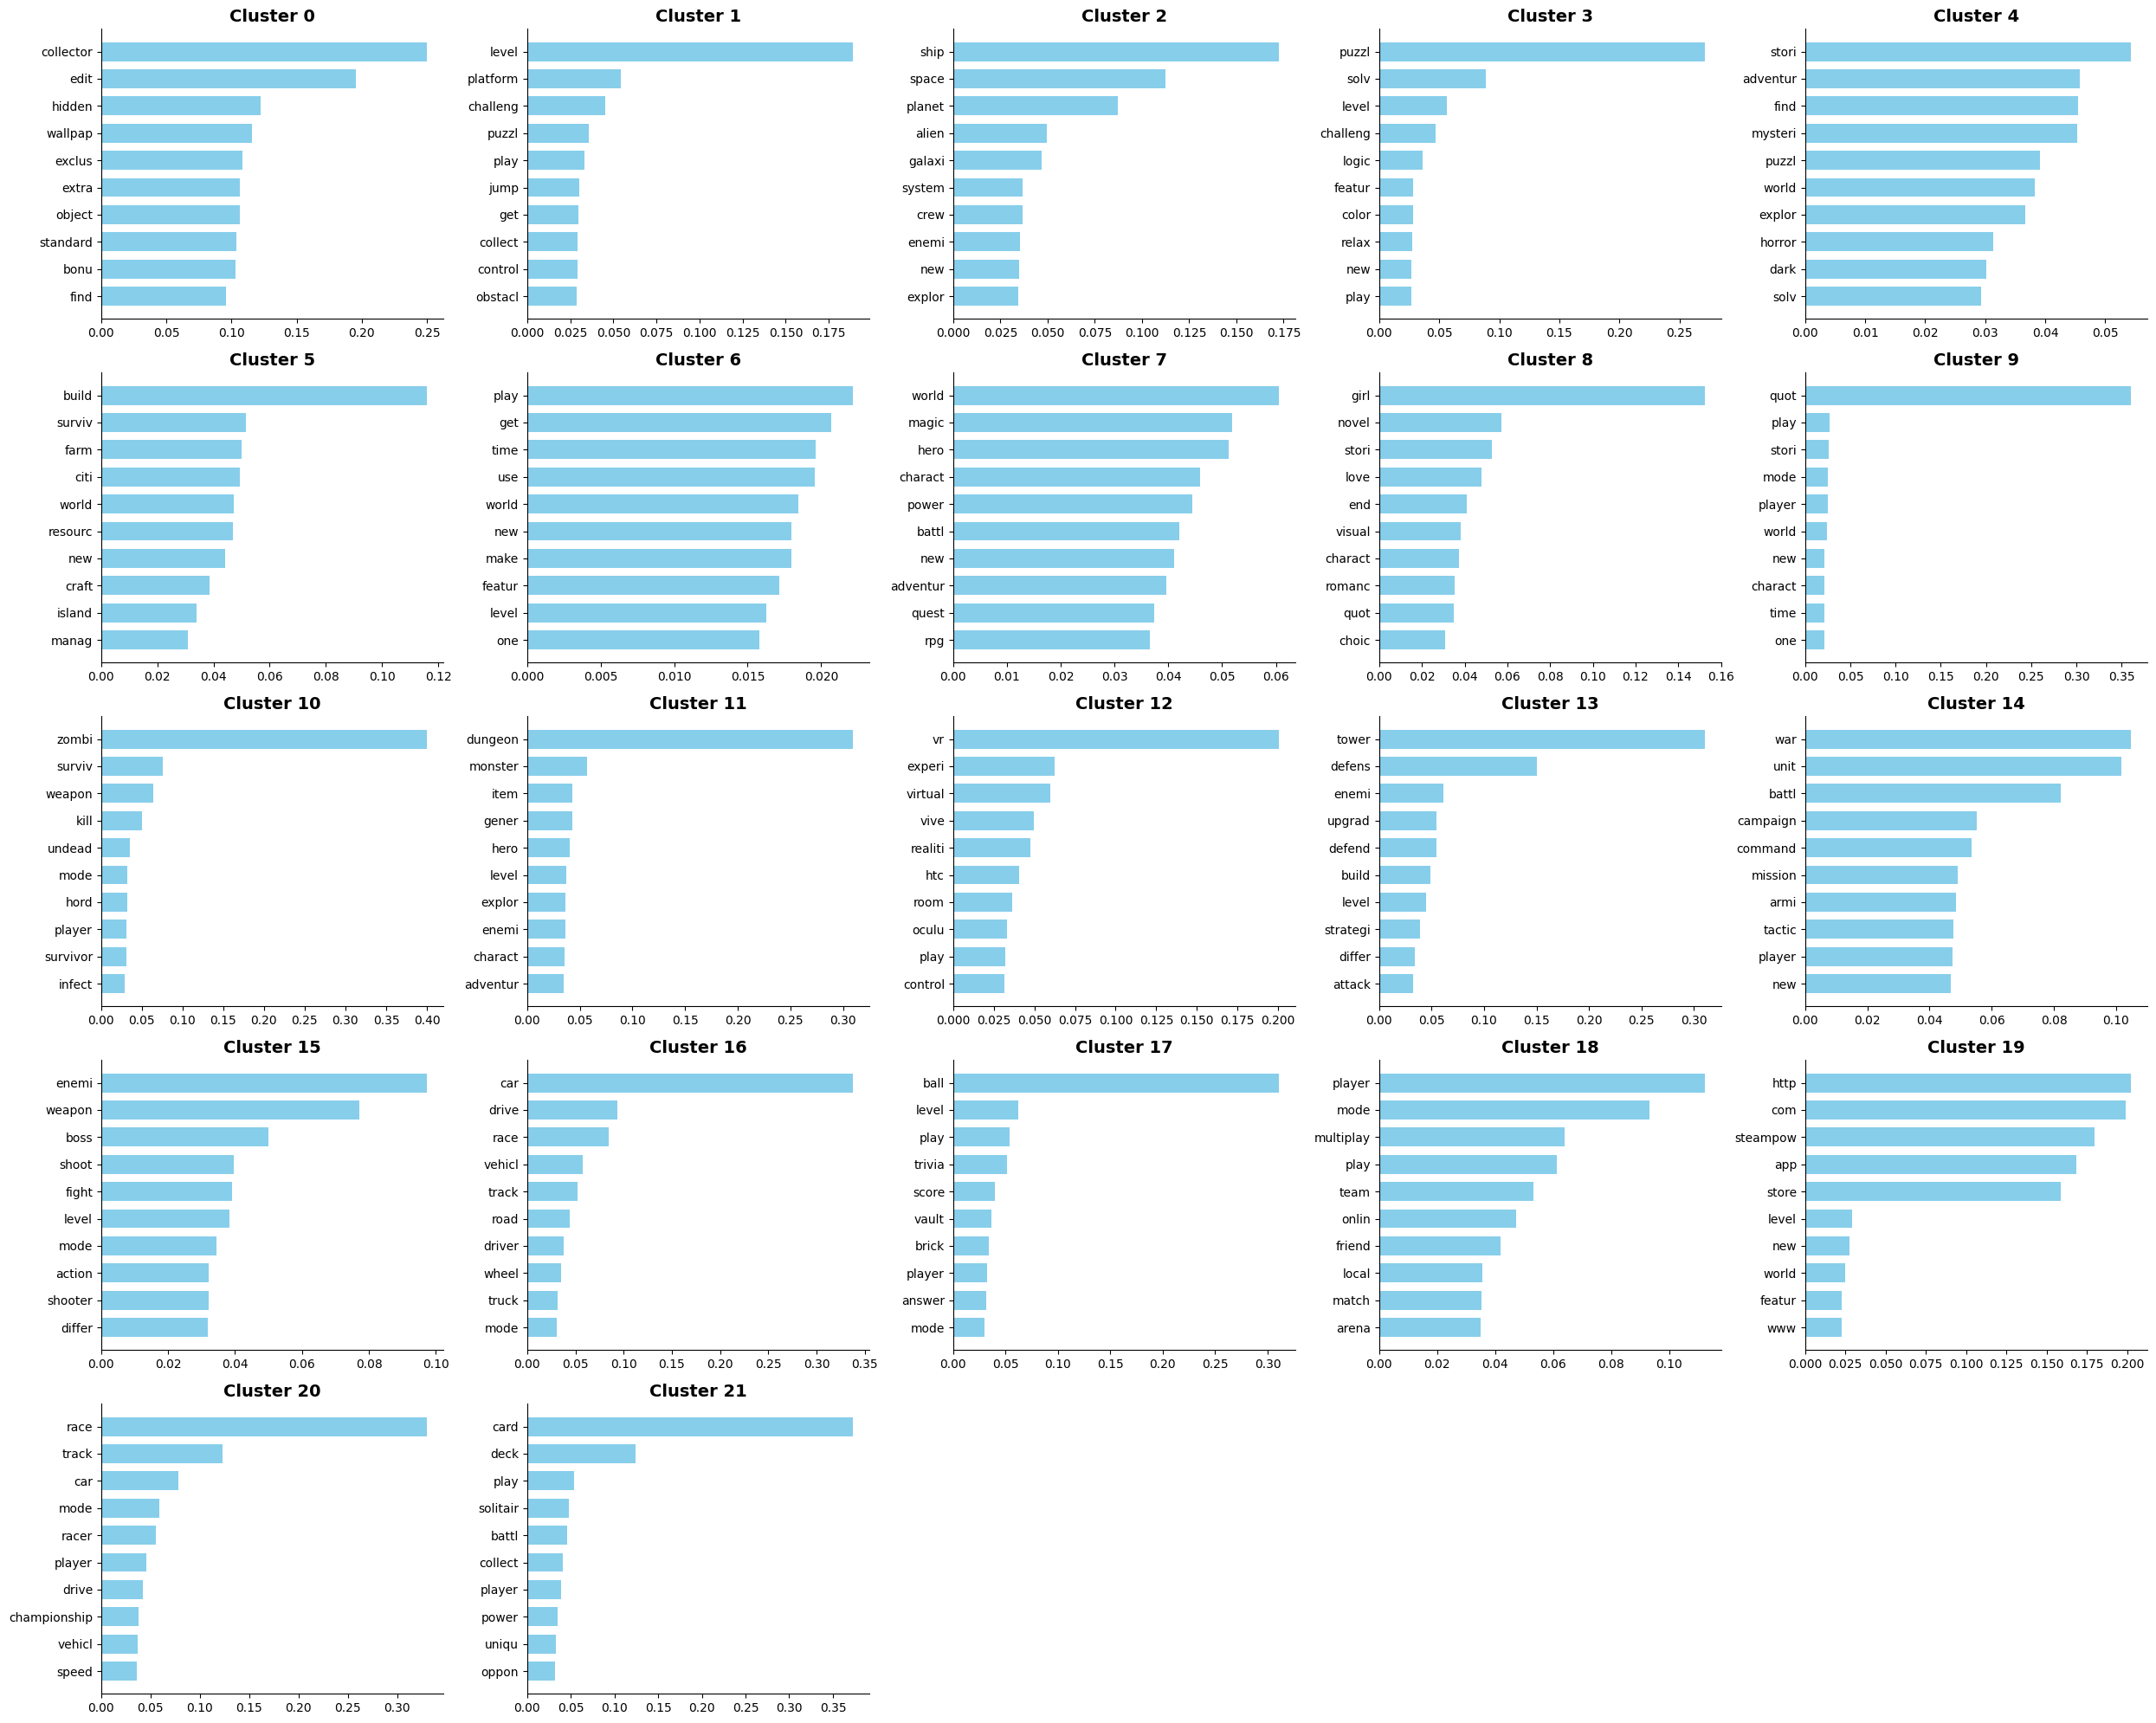

In [33]:
import matplotlib.pyplot as plt
import numpy as np
#mostra grafico de barras com as palavras(gemini)
def plot_kmeans_top_words(centroids, feature_names, n_top_words=10):
    n_clusters = centroids.shape[0]
    # Grid de 9 linhas x 5 colunas para caber 45 clusters
    rows = int(np.ceil(n_clusters / 5))
    cols = 5
    
    fig, axes = plt.subplots(rows, cols, figsize=(25, 4 * rows), sharex=False)
    axes = axes.flatten()

    for i in range(n_clusters):
        # Pegar os índices das palavras mais importantes (do maior para o menor)
        top_indices = centroids[i].argsort()[::-1][:n_top_words]
        top_words = [feature_names[ind] for ind in top_indices]
        top_weights = centroids[i][top_indices]
        
        ax = axes[i]
        # Plotar
        ax.barh(top_words, top_weights, height=0.7, color='skyblue')
        ax.set_title(f"Cluster {i}", fontsize=14, fontweight='bold')
        ax.invert_yaxis() # Palavra mais importante no topo
        ax.tick_params(axis='both', labelsize=10)
        
        # Limpar visual
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Remover subplots vazios se houver
    for i in range(n_clusters, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Chamada da função com seus dados
plot_kmeans_top_words(original_space_centroids, terms)

Agrupamento Aglomerativo
k=20 |Sillhouette: -0.003342 | CH: 27.03 | DB: 8.15
k=21 |Sillhouette: -0.003342 | CH: 26.52 | DB: 7.95
k=22 |Sillhouette: -0.003060 | CH: 26.04 | DB: 8.01
k=23 |Sillhouette: -0.002897 | CH: 25.59 | DB: 7.79
k=24 |Sillhouette: -0.003255 | CH: 25.15 | DB: 7.69


IndexError: index 3 is out of bounds for axis 0 with size 3

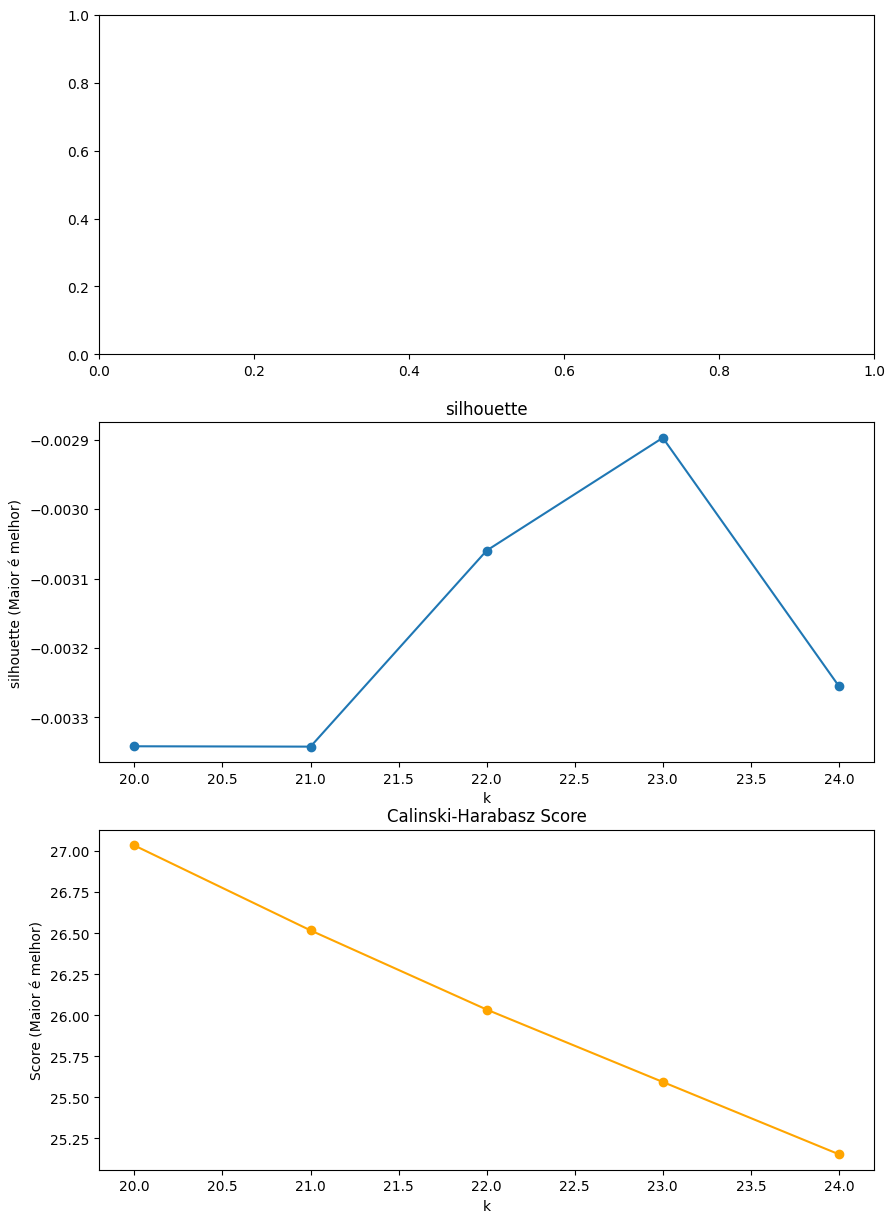

In [38]:
#Agrupamento aglomerativo
from sklearn.cluster import AgglomerativeClustering

range_cluster=range(20, 25)

inertia = []
silhouette = []
calinski = []
davies = []
print("Agrupamento Aglomerativo")
for n_clusters in range_cluster:
    clusterer = AgglomerativeClustering(n_clusters=n_clusters,linkage='ward',metric='euclidean')
    cluster_labels = clusterer.fit_predict(final_matrix)

    silhouette_avg = silhouette_score(final_matrix, cluster_labels)

    silhouette_avg = silhouette_score(final_matrix, cluster_labels)
    silhouette.append(silhouette_avg)
    
    score_ch = calinski_harabasz_score(final_matrix, cluster_labels)
    calinski.append(score_ch)
    
    score_db = davies_bouldin_score(final_matrix, cluster_labels)
    davies.append(score_db)

    print(f"k={n_clusters} |Sillhouette: {silhouette_avg:.6f} | CH: {score_ch:.2f} | DB: {score_db:.2f}")


fig, axes = plt.subplots(3, 1, figsize=(10, 15))


# Gráfico 1: silhouette
axes[1].plot(range_cluster, silhouette, marker='o')
axes[1].set_title('silhouette')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette (Maior é melhor)')
    
# Gráfico 3: Calinski-Harabasz
axes[2].plot(range_cluster, calinski, marker='o', color='orange')
axes[2].set_title('Calinski-Harabasz Score')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score (Maior é melhor)')

# Gráfico 4: Davies-Bouldin
axes[3].plot(range_cluster, davies, marker='o', color='green')
axes[3].set_title('Davies-Bouldin Index')
axes[3].set_xlabel('k')
axes[3].set_ylabel('Score (Menor é melhor)')

plt.tight_layout()
plt.show()